In [1]:
# 1. Импорты и настройки
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

IMG_SIZE = 224

# Это параметры
STEPS = 300
STEP_SIZE = 0.01
LAYER_NAMES = ["mixed6", "mixed7"]

print("Доступные устройства:")
print(tf.config.list_physical_devices())


Доступные устройства:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


Saving ih5Aln_buphKisVwdQW8DGnEachZNqdrVloIxlAkxnbC0Bkt-jn-j3cgXrXfMkBeLyHEJwy-wmTz9h3ELSopX9xr.jpg to ih5Aln_buphKisVwdQW8DGnEachZNqdrVloIxlAkxnbC0Bkt-jn-j3cgXrXfMkBeLyHEJwy-wmTz9h3ELSopX9xr.jpg
Файл загружен: ih5Aln_buphKisVwdQW8DGnEachZNqdrVloIxlAkxnbC0Bkt-jn-j3cgXrXfMkBeLyHEJwy-wmTz9h3ELSopX9xr.jpg


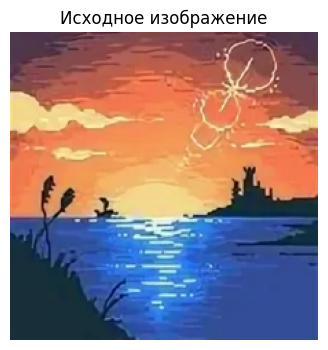

In [2]:
# 2. Загрузка изображения
uploaded = files.upload()

img_path = list(uploaded.keys())[0]
print("Файл загружен:", img_path)

original_pil = Image.open(img_path).convert("RGB")
original_pil = original_pil.resize((IMG_SIZE, IMG_SIZE))

plt.figure(figsize=(4, 4))
plt.imshow(np.array(original_pil) / 255.0)
plt.title("Исходное изображение")
plt.axis("off")
plt.show()


In [3]:
# 3. Создание модели DeepDream
base = tf.keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet"
)

outputs = [base.get_layer(name).output for name in LAYER_NAMES]

dream_model = tf.keras.Model(
    inputs=base.input,
    outputs=outputs
)

print("Используемые слои:", LAYER_NAMES)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Используемые слои: ['mixed6', 'mixed7']


In [4]:
# 4. Подготовка изображения для изменения
img_array = np.array(original_pil).astype(np.float32) / 255.0
dream_image = tf.Variable(img_array[None, ...])


In [5]:
# 5. Функции DeepDream
def calc_loss(image):
    prepared = tf.keras.applications.inception_v3.preprocess_input(image * 255.0)
    activations = dream_model(prepared)

    if not isinstance(activations, list):
        activations = [activations]

    loss = tf.constant(0.0)

    for activation in activations:
        loss += tf.reduce_mean(activation)

    return loss


@tf.function
def dream_step(image, step_size):
    with tf.GradientTape() as tape:
        tape.watch(image)
        loss = calc_loss(image)

    gradients = tape.gradient(loss, image)
    gradients = gradients / (tf.math.reduce_std(gradients) + 1e-8)

    image.assign_add(gradients * step_size)
    image.assign(tf.clip_by_value(image, 0.0, 1.0))

    return loss


Шаг: 0 loss: 0.23529869318008423
Шаг: 20 loss: 0.6888090372085571
Шаг: 40 loss: 0.8658859729766846
Шаг: 60 loss: 0.9738603830337524
Шаг: 80 loss: 1.0526559352874756
Шаг: 100 loss: 1.1113135814666748
Шаг: 120 loss: 1.1844868659973145
Шаг: 140 loss: 1.232109546661377
Шаг: 160 loss: 1.2638189792633057
Шаг: 180 loss: 1.3042149543762207
Шаг: 200 loss: 1.3283488750457764
Шаг: 220 loss: 1.3499442338943481
Шаг: 240 loss: 1.3957189321517944
Шаг: 260 loss: 1.4019001722335815
Шаг: 280 loss: 1.4357118606567383


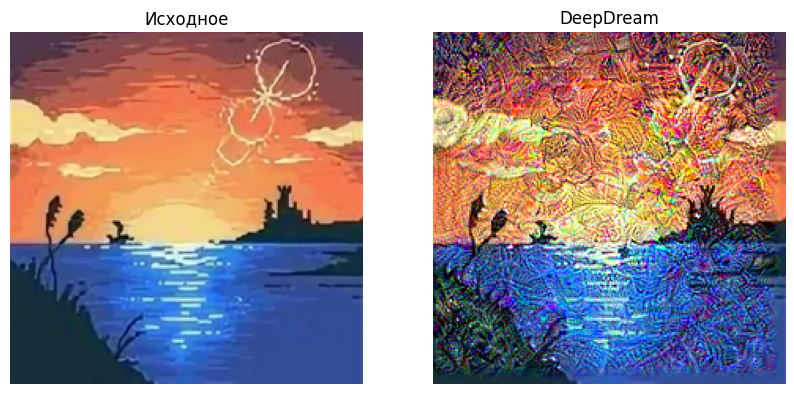

In [6]:
# 6. Генерация DeepDream
for step in range(STEPS):
    loss = dream_step(dream_image, STEP_SIZE)

    if step % 20 == 0:
        print("Шаг:", step, "loss:", float(loss))

result = dream_image[0].numpy()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.array(original_pil) / 255.0)
plt.title("Исходное")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title("DeepDream")
plt.axis("off")

plt.show()
